# 🍕 Pizza Place Sales Analysis
**Dataset:** A year's worth of sales from  Pizza Place (2015)  
**Files:** orders.csv · order_details.csv · pizzas.csv · pizza_types.csv  
**Goal:** Explore sales trends, determine the best/worst performers, determine peak hours of sales, and find revenue patterns.


## 1. Import Libraries & Load Data

In [1]:
# ── IMPORT LIBRARIES ──────────────────────────────────────────────────────────
import pandas as pd              # for data loading, merging, and analysis
import matplotlib.pyplot as plt  # for plotting charts
import matplotlib.ticker as mticker  # for formatting chart axis labels
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")  # applies a clean white background to all charts

In [2]:
# Importing the csv files including the data dictionary
# encoding='latin-1' handles special characters found in the ingredients column
orders        = pd.read_csv(r"C:\Users\user\Desktop\DATA SCIENCE\pizza_sales\orders.csv", encoding="latin-1")
order_details = pd.read_csv(r"C:\Users\user\Desktop\DATA SCIENCE\pizza_sales\order_details.csv", encoding="latin-1")
pizzas        = pd.read_csv(r"C:\Users\user\Desktop\DATA SCIENCE\pizza_sales\pizzas.csv", encoding="latin-1")
pizza_types   = pd.read_csv(r"C:\Users\user\Desktop\DATA SCIENCE\pizza_sales\pizza_types.csv", encoding="latin-1")
data_dictionary = pd.read_csv(r"C:\Users\user\Desktop\DATA SCIENCE\pizza_sales\data_dictionary.csv", encoding="latin-1")

print(f"   orders           : {orders.shape[0]:,} rows × {orders.shape[1]} cols")
print(f"   order_details    : {order_details.shape[0]:,} rows × {order_details.shape[1]} cols")
print(f"   pizzas           : {pizzas.shape[0]:,} rows × {pizzas.shape[1]} cols")
print(f"   pizza_types      : {pizza_types.shape[0]:,} rows × {pizza_types.shape[1]} cols")
print(f"   data_dictionary  : {data_dictionary.shape[0]:,} rows × {data_dictionary.shape[1]} cols")

   orders           : 21,350 rows × 3 cols
   order_details    : 48,620 rows × 4 cols
   pizzas           : 96 rows × 4 cols
   pizza_types      : 32 rows × 4 cols
   data_dictionary  : 15 rows × 3 cols


---
## 2. Merge All Four Files into One Dataframe

In [3]:
df= (order_details      
     .merge(orders, on='order_id')
     .merge(pizzas, on='pizza_id')
     .merge(pizza_types, on='pizza_type_id'))

# Start with order_details as the base (it has quantity and pizza_id)

#to confirm nothing got duplicated or dropped unexpectedly.
print(order_details.shape, df.shape)

df.isnull().sum() 

(48620, 4) (48620, 12)


order_details_id    0
order_id            0
pizza_id            0
quantity            0
date                0
time                0
pizza_type_id       0
size                0
price               0
name                0
category            0
ingredients         0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  48620 non-null  int64  
 1   order_id          48620 non-null  int64  
 2   pizza_id          48620 non-null  object 
 3   quantity          48620 non-null  int64  
 4   date              48620 non-null  object 
 5   time              48620 non-null  object 
 6   pizza_type_id     48620 non-null  object 
 7   size              48620 non-null  object 
 8   price             48620 non-null  float64
 9   name              48620 non-null  object 
 10  category          48620 non-null  object 
 11  ingredients       48620 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 4.5+ MB


In [5]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [6]:
# ── FEATURE ENGINEERING ───────────────────────────────────────────────────────
# Convert date column from string to datetime for date-based operations
df["date"] = pd.to_datetime(df["date"])

# Calculate revenue per row (quantity × price)
df["revenue"] = df["quantity"] * df["price"]

# Extract hour from time column for peak hours analysis
df["hour"] = pd.to_datetime(df["time"], format="%H:%M:%S").dt.hour

# Extract day name and month name for weekly and monthly trend analysis
df["day_of_week"] = df["date"].dt.day_name()
df["month"]       = df["date"].dt.month_name()
df["month_num"]   = df["date"].dt.month  # the numeric month for correct chronological sorting

print(f"   Combined dataframe: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
print("Columns:", list(df.columns))

   Combined dataframe: 48,620 rows × 17 columns

Columns: ['order_details_id', 'order_id', 'pizza_id', 'quantity', 'date', 'time', 'pizza_type_id', 'size', 'price', 'name', 'category', 'ingredients', 'revenue', 'hour', 'day_of_week', 'month', 'month_num']


In [7]:
# To preview the merged dataframe and confirm the merge looks correct
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,revenue,hour,day_of_week,month,month_num
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11,Thursday,January,1
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,11,Thursday,January,1
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,11,Thursday,January,1
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,11,Thursday,January,1
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,11,Thursday,January,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  48620 non-null  int64         
 1   order_id          48620 non-null  int64         
 2   pizza_id          48620 non-null  object        
 3   quantity          48620 non-null  int64         
 4   date              48620 non-null  datetime64[ns]
 5   time              48620 non-null  object        
 6   pizza_type_id     48620 non-null  object        
 7   size              48620 non-null  object        
 8   price             48620 non-null  float64       
 9   name              48620 non-null  object        
 10  category          48620 non-null  object        
 11  ingredients       48620 non-null  object        
 12  revenue           48620 non-null  float64       
 13  hour              48620 non-null  int32         
 14  day_of_week       4862

---
## 3. Key Business Metrics Overview

In [9]:
# ── QUESTION I: TOTAL REVENUE ─────────────────────────────────────────────────────────
total_revenue = df["revenue"].sum()   # sums all revenue values across every row
print(f"💰 Total Revenue       : ${total_revenue:,.2f}")

# ── QUESTION II: TOTAL QUANTITY SOLD ───────────────────────────────────────────────────
total_quantity = df["quantity"].sum()   # sums all pizza quantities ordered
print(f"🍕 Total Pizzas Sold   : {total_quantity:,}")

# ── QUESTION III: TOTAL ORDERS ──────────────────────────────────────────────────────────

total_orders = df["order_id"].nunique()  # nunique() counts distinct order IDs to avoid counting the same order twice
print(f"📋 Total Orders        : {total_orders:,}") 

# ── QUESTION IV: NUMBER OF PIZZA TYPES ─────────────────────────────────────────────────
pizza_type_count = df["pizza_type_id"].nunique()   # count unique pizza types
print(f"🧾 Unique Pizza Types  : {pizza_type_count}")

# ── QUESTION V: AVERAGE PIZZA PRICE ───────────────────────────────────────────────────
# Use the pizzas table directly — each row is one unique pizza SKU
avg_price = pizzas["price"].mean()
print(f"💵 Average Pizza Price : ${avg_price:.2f}")

💰 Total Revenue       : $817,860.05
🍕 Total Pizzas Sold   : 49,574
📋 Total Orders        : 21,350
🧾 Unique Pizza Types  : 32
💵 Average Pizza Price : $16.44


### 🔍 Insight
In 2015, the pizza place generated **\$817,860** in total revenue from **21,350 orders**,
selling **49,574 pizzas** across **32 unique pizza types** at an average price of **\$16.44**.
This averages roughly **\$2,240 in revenue per day**.

---
## QUESTION VI: Peak Hours of Sales

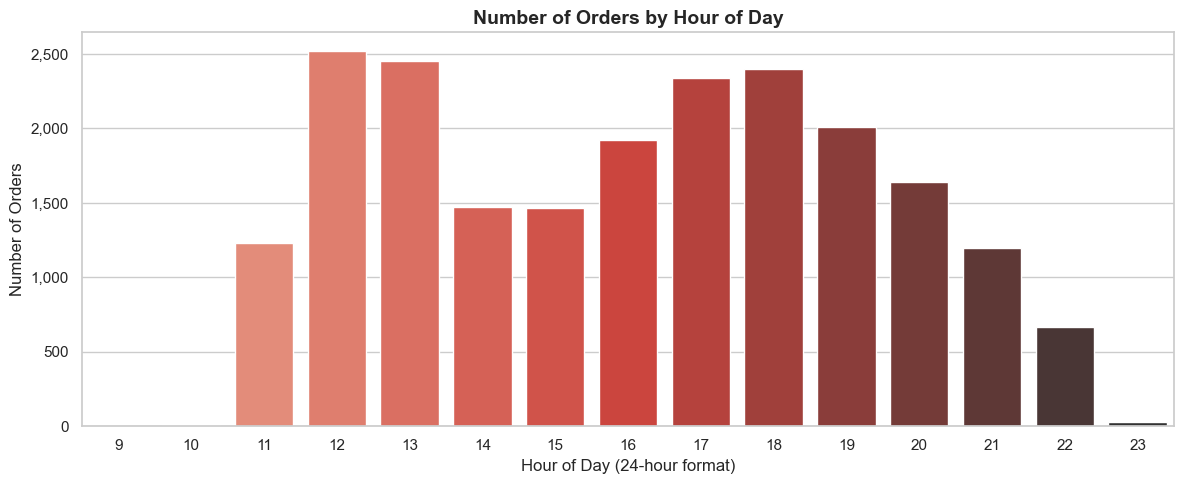


Top 5 Busiest Hours:
 hour  orders
   12    2520
   13    2455
   18    2399
   17    2336
   19    2009


In [10]:
# ── COUNT UNIQUE ORDERS PER HOUR ──────────────────────────────────────────────
# nunique() on order_id gives actual orders per hour, not just row counts
hourly_orders = (df.groupby("hour")["order_id"]
                   .nunique()
                   .sort_index()           # sort by hour 0–23 for a clean timeline
                   .reset_index())         # reset index so seaborn can read x and y easily

# Rename columns for clarity in the chart
hourly_orders.columns = ["hour", "orders"]

# ── PLOT PEAK HOURS BAR CHART WITH SEABORN ────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(data=hourly_orders,
            x="hour",
            y="orders",
            hue="hour", 
            palette="Reds_d",
            legend=False,   # darker red = more orders — gives visual weight to busiest hours
            ax=ax)

ax.set_title("Number of Orders by Hour of Day", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of Day (24-hour format)")
ax.set_ylabel("Number of Orders")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

# Print the top 5 busiest hours as numbers below the chart
print("\nTop 5 Busiest Hours:")
print(hourly_orders.sort_values("orders", ascending=False).head().to_string(index=False))


### 🔍 Insight
> The busiest hours are **12pm (2,520 orders)**, **1pm (2,455)**, and **6pm (2,399)**,
> clearly reflecting **lunch and dinner rush periods**.
> The restaurant is quietest after 9pm and before 11am.
> Staffing and prep should be heaviest between **12–1pm** and **6–8pm**.

---
## QUESTION VII: Total Sales by Day of the Week

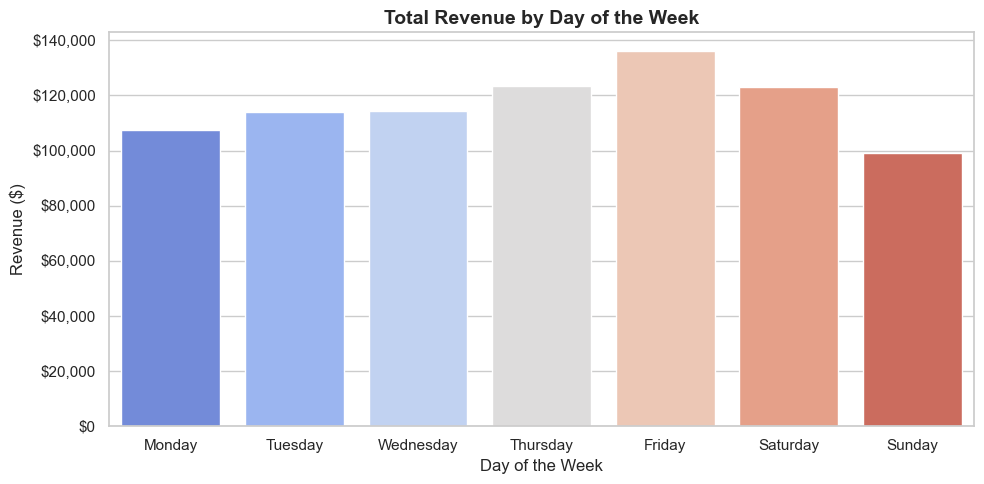

Revenue by Day of the Week:
  Monday       : $107,329.55
  Tuesday      : $114,133.80
  Wednesday    : $114,408.40
  Thursday     : $123,528.50
  Friday       : $136,073.90 ← HIGHEST
  Saturday     : $123,182.40
  Sunday       : $ 99,203.50


In [11]:
# ── ORDER DAYS IN CORRECT WEEK SEQUENCE ──────────────────────────────────────
day_order    = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sales_by_day = (df.groupby("day_of_week")["revenue"]
                  .sum()
                  .reindex(day_order)     # reindex forces Mon–Sun order instead of alphabetical
                  .reset_index())

# Rename columns for seaborn
sales_by_day.columns = ["day", "revenue"]

# ── PLOT SALES BY DAY WITH SEABORN ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=sales_by_day,
            x="day",
            y="revenue",
            hue="day",
            palette="coolwarm",   # cool colours for low days, warm for high days
            legend=False,
            ax=ax)

ax.set_title("Total Revenue by Day of the Week", fontsize=14, fontweight="bold")
ax.set_xlabel("Day of the Week")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

# To print exact revenue figures for every day
print("Revenue by Day of the Week:")
for _, row in sales_by_day.iterrows():
    marker = " ← HIGHEST" if row["day"] == sales_by_day.loc[sales_by_day["revenue"].idxmax(), "day"] else ""
    print(f"  {row['day']:<12} : ${row['revenue']:>10,.2f}{marker}")

### 🔍 Insight


> **Friday is the strongest sales day** at \\$136,074 — nearly 37\% more than Sunday ($99,204).
>
> The weekday trend rises steadily from Monday to Friday, then dips over the weekend.
>
> Sunday is consistently the slowest day and a good candidate for targeted promotions.

---
## QUESTION VIII: Top 5 Best-Selling Pizzas

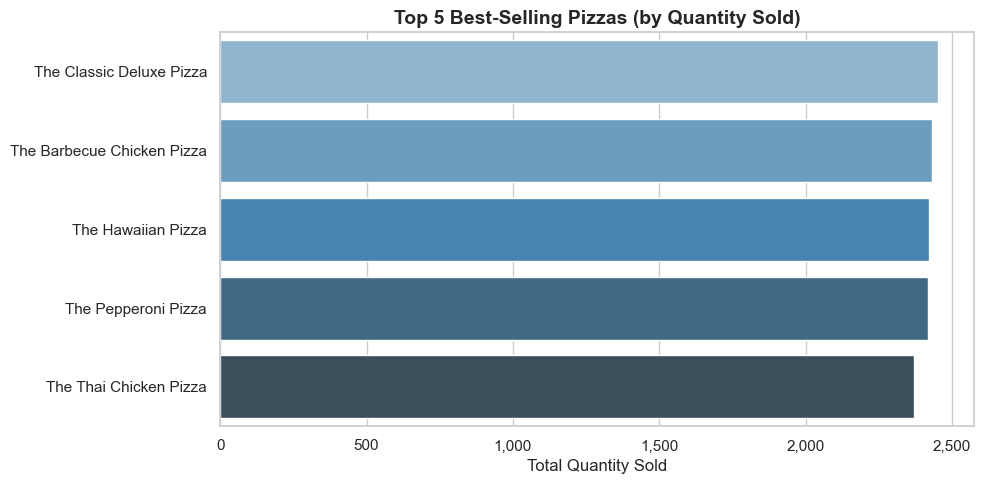


Top 5 Best-Selling Pizzas:
  1. The Classic Deluxe Pizza            2,453 units
  2. The Barbecue Chicken Pizza          2,432 units
  3. The Hawaiian Pizza                  2,422 units
  4. The Pepperoni Pizza                 2,418 units
  5. The Thai Chicken Pizza              2,371 units


In [12]:
# ── TOTAL QUANTITY SOLD PER PIZZA NAME ────────────────────────────────────────
top5 = (df.groupby("name")["quantity"]
          .sum()
          .sort_values(ascending=False)
          .head(5)                         # keep only the top 5 sellers
          .reset_index())

# Rename columns for seaborn
top5.columns = ["pizza", "quantity"]

# ── PLOT HORIZONTAL BAR CHART WITH SEABORN  ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=top5,
            x="quantity",
            y="pizza",
            hue="pizza",
            palette="Blues_d",    # darker blue = higher quantity
            orient="h",           # horizontal bars for long pizza names
            legend=False,
            ax=ax)

ax.set_title("Top 5 Best-Selling Pizzas (by Quantity Sold)", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Quantity Sold")
ax.set_ylabel("")                  # no y-axis label needed — pizza names are self-explanatory
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print("\nTop 5 Best-Selling Pizzas:")
for rank, row in enumerate(top5.itertuples(), 1):
    print(f"  {rank}. {row.pizza:<35} {row.quantity:,} units")

### 🔍 Insight
> The **Classic Deluxe Pizza** leads with 2,453 units, closely followed by
> **Barbecue Chicken (2,432)**, **Hawaiian (2,422)**, **Pepperoni (2,418)**, and **Thai Chicken (2,371)**.
> The top 5 are remarkably close in sales; no single pizza dominates heavily,
> suggesting a well-balanced and popular menu.

---
## QUESTION IX: Monthly Sales Trend

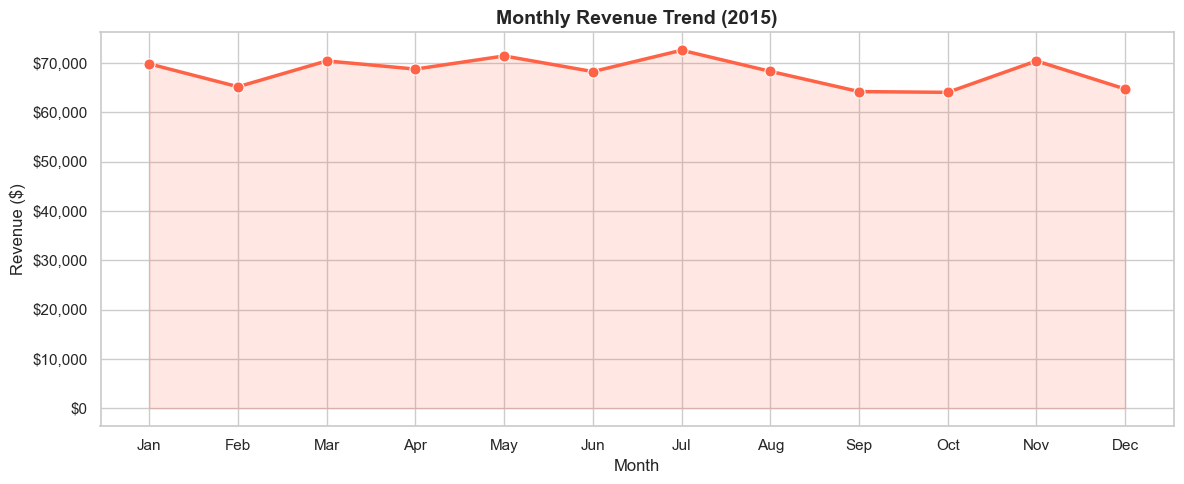

Monthly Revenue:
  Jan   : $ 69,793.30
  Feb   : $ 65,159.60
  Mar   : $ 70,397.10
  Apr   : $ 68,736.80
  May   : $ 71,402.75
  Jun   : $ 68,230.20
  Jul   : $ 72,557.90
  Aug   : $ 68,278.25
  Sep   : $ 64,180.05
  Oct   : $ 64,027.60
  Nov   : $ 70,395.35
  Dec   : $ 64,701.15


In [13]:
# ── MONTHLY REVENUE ───────────────────────────────────────────────────────────
# Group by month_num (numeric) to sort chronologically Jan–Dec
monthly_sales = (df.groupby("month_num")["revenue"]
                   .sum()
                   .reset_index())

# Map numeric month to short name for readable x-axis labels
month_names = {1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr",  5:"May",  6:"Jun",
               7:"Jul", 8:"Aug", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"}
monthly_sales["month_label"] = monthly_sales["month_num"].map(month_names)

# ── PLOT LINE CHART WITH WITH SEABORN ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(data=monthly_sales,
             x="month_label",
             y="revenue",
             marker="o",          # circle marker on each data point
             color="tomato",
             linewidth=2.5,
             markersize=8,
             ax=ax)

# Fill the area under the line for stronger visual impact
ax.fill_between(monthly_sales["month_label"],
                monthly_sales["revenue"],
                alpha=0.15, color="tomato")

ax.set_title("Monthly Revenue Trend (2015)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

# Print exact monthly figures
print("Monthly Revenue:")
for _, row in monthly_sales.iterrows():
    print(f"  {row['month_label']:<5} : ${row['revenue']:>10,.2f}")

### 🔍 Insight
> **July is the peak revenue month (\\$72,558)**, while **October is the slowest (\$64,028)**. Revenue is stable throughout the year within an $8,500 range, suggesting consistent demand with a mild **summer peak (May–July)**. The dip from August through October could be addressed with seasonal promotions.

---
## QUESTION X: Underperforming Pizzas

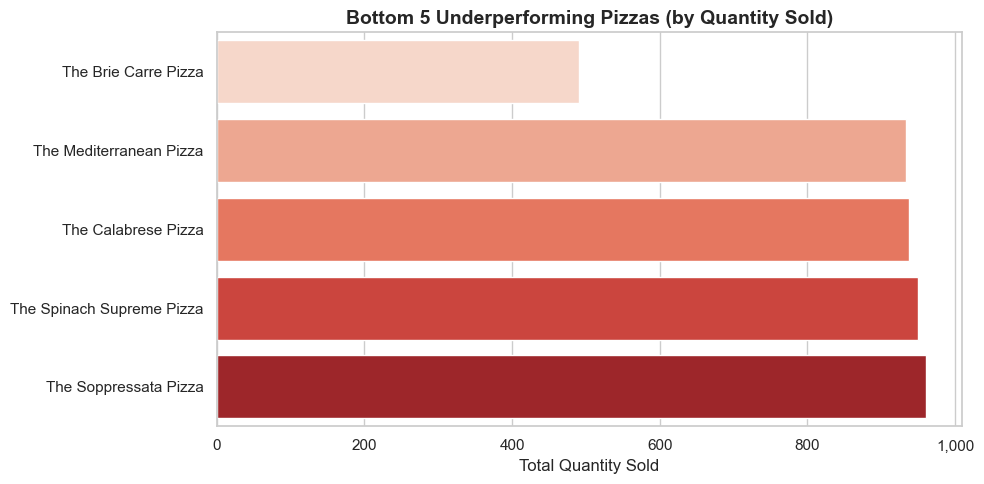


Bottom 5 Underperforming Pizzas:
  1. The Brie Carre Pizza                   490 units
  2. The Mediterranean Pizza                934 units
  3. The Calabrese Pizza                    937 units
  4. The Spinach Supreme Pizza              950 units
  5. The Soppressata Pizza                  961 units


In [14]:
# ── BOTTOM 5 PIZZAS BY TOTAL QUANTITY SOLD ────────────────────────────────────
bottom5 = (df.groupby("name")["quantity"]
             .sum()
             .sort_values(ascending=True)
             .head(5)                       # keep only the 5 lowest-selling pizzas
             .reset_index())

# Rename columns for seaborn
bottom5.columns = ["pizza", "quantity"]

# ── PLOT HORIZONTAL BAR CHART WITH SEABORN ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=bottom5,
            x="quantity",
            y="pizza",
            hue="pizza",
            palette="Reds",       # red palette signals poor performance visually
            orient="h",
            legend=False,
            ax=ax)

ax.set_title("Bottom 5 Underperforming Pizzas (by Quantity Sold)", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Quantity Sold")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print("\nBottom 5 Underperforming Pizzas:")
for rank, row in enumerate(bottom5.itertuples(), 1):
    print(f"  {rank}. {row.pizza:<38} {row.quantity:,} units")

### 🔍 Insight
> **The Brie Carre Pizza** is the worst performer with only 490 units sold —
> nearly **5× fewer** than the top seller.
> Management should consider **removing or reformulating** these items,
> or running targeted promotions before pulling them from the menu entirely.

---
## Other Exploratory Data Analysis — Revenue by Pizza Category

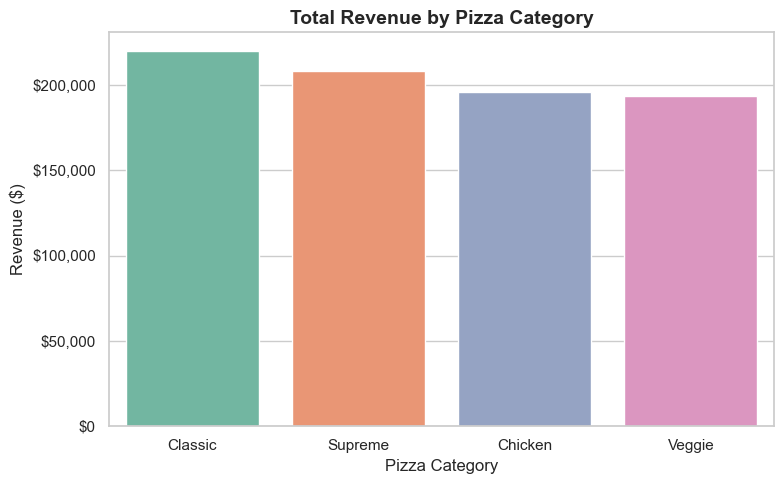

Revenue by Category:
  Classic    : $220,053.10  (26.9%)
  Supreme    : $208,197.00  (25.5%)
  Chicken    : $195,919.50  (24.0%)
  Veggie     : $193,690.45  (23.7%)


In [15]:
# ── GROUP BY PIZZA CATEGORY ───────────────────────────────────────────────────
# Categories are: Classic, Chicken, Supreme, Veggie
category_revenue = (df.groupby("category")["revenue"]
                      .sum()
                      .sort_values(ascending=False)
                      .reset_index())

# Rename columns for seaborn
category_revenue.columns = ["category", "revenue"]

# ── PLOT BAR CHART WITH SEABORN ───────────────────────────────────────────────
# A bar chart is used here instead of a pie chart — it is easier to read precise values
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=category_revenue,
            x="category",
            y="revenue",
            hue="category",
            palette="Set2",   # Set2 gives distinct, professional colours per category
            legend=False,
            ax=ax)

ax.set_title("Total Revenue by Pizza Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Pizza Category")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

# Print revenue and percentage share per category
print("Revenue by Category:")
total = category_revenue["revenue"].sum()
for _, row in category_revenue.iterrows():
    pct = row["revenue"] / total * 100
    print(f"  {row['category']:<10} : ${row['revenue']:>10,.2f}  ({pct:.1f}%)")


### 🔍 Insight
> **Classic pizzas generate the most revenue (26.9%)**, followed by Supreme (25.5%),
> Chicken (23.9%), and Veggie (23.7%).
> Revenue is remarkably balanced across all four categories,
> showing the menu is well-diversified with no single category dominating.

---
## Other Exploratory Data Analysis — Sales by Pizza Size

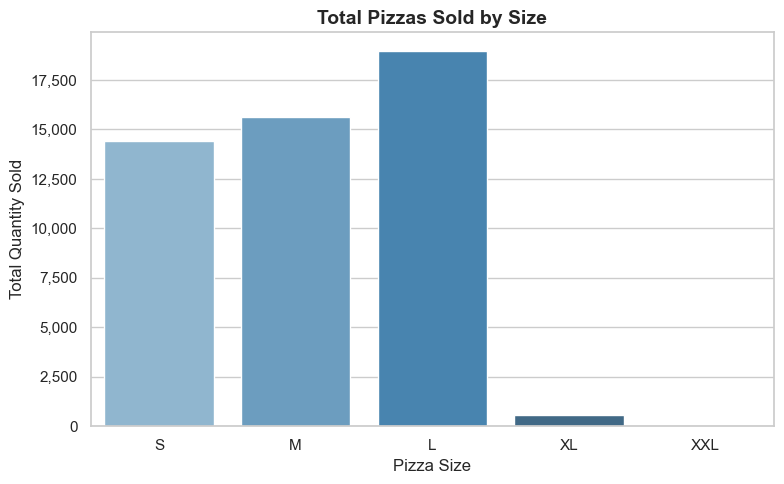

Sales by Size:
  Size S     : 14,403 units
  Size M     : 15,635 units
  Size L     : 18,956 units
  Size XL    : 552 units
  Size XXL   : 28 units


In [16]:
# ── GROUP BY PIZZA SIZE ───────────────────────────────────────────────────────
size_order = ["S", "M", "L", "XL", "XXL"]   # define logical S → XXL order

size_sales = (df.groupby("size")["quantity"]
                .sum()
                .reindex(size_order)
                .dropna()                    # drop any sizes that have no sales data
                .reset_index())

# Rename columns for seaborn
size_sales.columns = ["size", "quantity"]

# ── PLOT BAR CHART WITH SEABORN ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=size_sales,
            x="size",
            y="quantity",
            hue="size",
            palette="Blues_d",    # darker blue = higher quantity sold
            legend=False,
            ax=ax)

ax.set_title("Total Pizzas Sold by Size", fontsize=14, fontweight="bold")
ax.set_xlabel("Pizza Size")
ax.set_ylabel("Total Quantity Sold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print("Sales by Size:")
for _, row in size_sales.iterrows():
    print(f"  Size {row['size']:<5} : {int(row['quantity']):,} units")

### 🔍 Insight
> **Large pizzas are the most popular size**, followed by Medium and Small.
> XL and XXL have very low sales, suggesting the pricing premium discourages purchases.
> Bundling XL/XXL with deals could help boost those sizes.

---
## 📊 Summary of Key Findings

| Metric | Value |
|--------|-------|
| Total Revenue | \$817,860 |
| Total Orders | 21,350 |
| Total Pizzas Sold | 49,574 |
| Unique Pizza Types | 32 |
| Average Pizza Price | $16.44 |
| Busiest Hour | 12pm |
| Best Day | Friday |
| Best Month | July |
| Top Pizza | Classic Deluxe |
| Worst Pizza | Brie Carre |

> **Overall**, the pizza place runs a healthy and consistent operation.  
> The key opportunities lie in **boosting Sunday sales**, **promoting slow menu items**,
> and **capitalising on the lunch and dinner rush** with targeted staffing strategies.